# Portfolio rebalancing with versioned holdings

A portfolio book is the canonical versioned dataset: every rebalance is a
commit, every commit has a note, and questions like "what did we hold
after the March rebalance?" or "how much did we trade in January?" are
version queries, not spreadsheet archaeology. This recipe runs a monthly
momentum portfolio on real data (30 S&P names, 2018-2026) and uses
h5i-db's version chain as the system of record:

1. `prices` table from real daily closes; 12-1 momentum in SQL,
2. a `holdings` table appended once per rebalance — one commit per
   rebalance, with a note — plus an audit snapshot,
3. turnover and trade lists reconstructed *from version diffs* with
   `h5i('holdings', v)` in SQL,
4. NAV vs benchmark, weight drift between rebalances, and point-in-time
   book reconstruction.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_rebalance"), create=True)

## 1. Real prices in, momentum out

Split-adjusted closes for 30 liquid names. The 12-1 momentum signal —
trailing 12-month return excluding the most recent month, the classic
formation rule — is two `lag()` windows in SQL: `lag(adj_close, 21)` over
`lag(adj_close, 252)` on the trading-day series, per symbol.

In [2]:
raw = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01").to_pandas()
px_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("adj_close", pa.float64()),
    ]
)
db.create_table("prices", px_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "prices",
    pa.Table.from_pandas(
        raw[["ts", "symbol", "adj_close"]].sort_values(["ts", "symbol"]), preserve_index=False
    ).cast(px_schema),
    note="30 S&P names, 2018-2026, split-adjusted",
)

mom_df = db.sql(
    """
    SELECT ts, symbol, adj_close,
           lag(adj_close, 21)  OVER w / lag(adj_close, 252) OVER w - 1 AS mom
    FROM prices
    WINDOW w AS (PARTITION BY symbol ORDER BY ts)
    ORDER BY ts, symbol
    """
).to_pandas()
px = mom_df.pivot(index="ts", columns="symbol", values="adj_close")
mom = mom_df.pivot(index="ts", columns="symbol", values="mom")
print(f"{px.shape[0]} trading days x {px.shape[1]} symbols")

2134 trading days x 30 symbols


## 2. The rebalance loop: one commit per rebalance

Monthly, 2023-01 through 2026-06: rank on momentum, hold the top 10
equal-weight, trade at that session's close, pay 10 bps on traded
notional. Each rebalance appends that day's book (shares, price, weight
per held name) to `holdings` — an atomic commit carrying a
`note="rebalance YYYY-MM"`. The book *history* is append-only; the *state*
at any version is "the rows at that version's latest timestamp". At the
December 2025 rebalance we also cut a named snapshot, the audit anchor a
year-end review would ask for.

In [3]:
hold_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("shares", pa.float64()),
        pa.field("price", pa.float64()),
        pa.field("weight", pa.float64()),
    ]
)
db.create_table("holdings", hold_schema, time_column="ts", sort_key=["ts", "symbol"])

month_ends = (
    px.loc["2023-01-01":"2026-06-30"].groupby([px.loc["2023-01-01":"2026-06-30"].index.year,
                                               px.loc["2023-01-01":"2026-06-30"].index.month])
    .apply(lambda g: g.index.max())
    .tolist()
)

TOP_N, COST_BPS = 10, 10
nav, shares = 10_000_000.0, pd.Series(dtype=float)
ledger = []  # (date, nav_pre, cost, turnover) per rebalance

for reb_ts in month_ends:
    p = px.loc[reb_ts]
    nav_pre = float((shares * p).sum()) if len(shares) else nav
    winners = mom.loc[reb_ts].dropna().nlargest(TOP_N).index
    # two-pass so costs are funded out of NAV before sizing
    target = pd.Series(nav_pre / TOP_N, index=winners) / p[winners]
    traded = (target.reindex(p.index, fill_value=0.0) - shares.reindex(p.index, fill_value=0.0)).abs()
    cost = float((traded * p).sum()) * COST_BPS / 1e4
    nav_post = nav_pre - cost
    shares = pd.Series(nav_post / TOP_N, index=winners) / p[winners]
    ledger.append((reb_ts, nav_pre, cost, float((traded * p).sum()) / nav_pre))

    ym = f"{reb_ts.year}-{reb_ts.month:02d}"
    book = pd.DataFrame(
        {
            "ts": reb_ts,
            "symbol": winners,
            "shares": shares[winners].to_numpy(),
            "price": p[winners].to_numpy(),
            "weight": (shares[winners] * p[winners]).to_numpy() / nav_post,
        }
    ).sort_values(["ts", "symbol"])
    db.append("holdings", pa.Table.from_pandas(book, preserve_index=False).cast(hold_schema),
              note=f"rebalance {ym}")
    if ym == "2025-12":
        db.snapshot("eoy-2025", tables=["holdings"], note="year-end audit anchor")

versions = db.versions("holdings")
print(f"{len(month_ends)} rebalances -> {len(versions)} versions; last notes:")
for v in versions[-3:]:
    print(f"  v{v['sequence']:>2}  {v['op']:<7} {v['rows']:>3} rows  note={v.get('note')!r}")

42 rebalances -> 43 versions; last notes:
  v40  append  400 rows  note='rebalance 2026-04'
  v41  append  410 rows  note='rebalance 2026-05'
  v42  append  420 rows  note='rebalance 2026-06'


## 3. Trade lists and turnover from version diffs

Nothing in the loop wrote a "trades" table — it does not need to exist.
The trade list *is* the difference between consecutive versions of the
book. `h5i('holdings', v)` exposes any version to SQL, so a FULL OUTER
JOIN of version `v`'s latest book against version `v-1`'s reconstructs
exactly what was bought and sold, including entries and exits:

In [4]:
head = versions[-1]["sequence"]

def book_ts(v):
    """Timestamp of the latest book inside version v of `holdings`."""
    return db.sql(f"SELECT max(ts) AS m FROM h5i('holdings', {v})").to_pandas()["m"][0]

# Resolve each version's book timestamp first and inline it as a literal:
# the current build mis-plans joins whose inputs both carry scalar
# subqueries, silently matching nothing — two steps keep the diff correct.
# px_now marks every leg (including exits) at the rebalance-date close.
def book_diff_sql(v_new, v_old, select):
    return f"""
    WITH cur AS (SELECT symbol, shares, price FROM h5i('holdings', {v_new})
                 WHERE ts = TIMESTAMP '{book_ts(v_new)}'),
         prev AS (SELECT symbol, shares, price FROM h5i('holdings', {v_old})
                  WHERE ts = TIMESTAMP '{book_ts(v_old)}'),
         px_now AS (SELECT symbol, adj_close FROM prices
                    WHERE ts = TIMESTAMP '{book_ts(v_new)}')
    {select}
    """

trade_list = db.sql(
    book_diff_sql(
        head,
        head - 1,
        """
        SELECT COALESCE(cur.symbol, prev.symbol)               AS symbol,
               COALESCE(prev.shares, 0)                        AS shares_before,
               COALESCE(cur.shares, 0)                         AS shares_after,
               COALESCE(cur.shares, 0) - COALESCE(prev.shares, 0) AS trade_shares,
               px_now.adj_close                                AS price
        FROM cur FULL OUTER JOIN prev ON cur.symbol = prev.symbol
        JOIN px_now ON px_now.symbol = COALESCE(cur.symbol, prev.symbol)
        ORDER BY trade_shares
        """,
    )
).to_pandas()
assert len(trade_list) >= TOP_N, "diff must cover holds, entries and exits"
trade_list.round(1)

,symbol,shares_before,shares_after,trade_shares,price
0,MRK,19272.6,17791.9,-1480.7,128.5
1,JNJ,10081.7,9002.1,-1079.6,254.0
2,CAT,2598.5,2150.9,-447.6,1062.9
3,GS,2224.8,2260.6,35.7,1011.4
4,GOOGL,5976.4,6397.5,421.1,357.4
5,CSCO,18935.4,19537.0,601.5,117.0
6,AAPL,7279.7,7901.1,621.4,289.4
7,NVDA,10771.8,11426.1,654.4,200.1
8,XOM,15638.9,16722.2,1083.3,136.7
9,CVX,12450.4,13792.6,1342.2,165.8


The same diff, aggregated, gives per-rebalance traded notional and
two-way turnover — an audit-grade number derived purely from committed
versions, which we cross-check against the loop's own ledger.

In [5]:
turnover_rows = []
for v in range(2, head + 1):
    r = db.sql(
        book_diff_sql(
            v,
            v - 1,
            """
            , j AS (SELECT COALESCE(cur.shares, 0) - COALESCE(prev.shares, 0) AS d,
                           px_now.adj_close AS p2
                    FROM cur FULL OUTER JOIN prev ON cur.symbol = prev.symbol
                    JOIN px_now ON px_now.symbol = COALESCE(cur.symbol, prev.symbol))
            SELECT sum(abs(d) * p2)                          AS traded,
                   (SELECT sum(shares * price) FROM cur)     AS book_value
            FROM j
            """,
        )
    ).to_pandas()
    turnover_rows.append(
        {"version": v, "traded": r["traded"][0], "turnover": r["traded"][0] / r["book_value"][0]}
    )
turn = pd.DataFrame(turnover_rows)
turn["date"] = [d for d, *_ in ledger[1:]]

ledger_turnover = np.array([t for *_, t in ledger[1:]])
assert np.allclose(turn["turnover"], ledger_turnover, atol=2e-3), "version diff vs ledger"
print(f"version-diff turnover matches the loop's ledger; mean two-way turnover "
      f"{turn['turnover'].mean():.1%} per month")

version-diff turnover matches the loop's ledger; mean two-way turnover 43.0% per month


## 4. NAV, benchmark, and drift between rebalances

Daily NAV is just held shares marked on the price panel. The benchmark is
the equal-weight 30-name portfolio (daily rebalanced, no costs — a hard
bar). Between rebalances the book drifts off its equal-weight targets;
the L1 drift `0.5 * sum|w - w_target|` shows the sawtooth that monthly
rebalancing tolerates.

In [6]:
start_ts = month_ends[0]
days = px.index[px.index >= start_ts]
nav_daily, drift_daily = [], []
k = -1
for d in days:
    if k + 1 < len(month_ends) and d >= month_ends[k + 1]:
        k += 1
        reb_us = int(month_ends[k].value // 1000)
        book_shares = (
            db.read("holdings", time_start=reb_us, time_end=reb_us + 1)
            .to_pandas()
            .set_index("symbol")["shares"]
        )
    vals = book_shares * px.loc[d, book_shares.index]
    nav_daily.append(vals.sum())
    w = vals / vals.sum()
    drift_daily.append(0.5 * (w - 1 / TOP_N).abs().sum())

nav_s = pd.Series(nav_daily, index=days)
drift_s = pd.Series(drift_daily, index=days)
bench = (1 + px.loc[days].pct_change().mean(axis=1).fillna(0)).cumprod() * 10_000_000

def stats(series):
    r = series.pct_change().dropna()
    dd = (series / series.cummax() - 1).min()
    return {
        "ann. return": (series.iloc[-1] / series.iloc[0]) ** (252 / len(r)) - 1,
        "ann. vol": r.std() * np.sqrt(252),
        "Sharpe": r.mean() / r.std() * np.sqrt(252),
        "max drawdown": dd,
    }

pd.DataFrame({"momentum top-10": stats(nav_s), "equal-weight 30": stats(bench)}).T.round(3)

,ann. return,ann. vol,Sharpe,max drawdown
momentum top-10,0.276,0.175,1.479,-0.224
equal-weight 30,0.246,0.119,1.909,-0.146


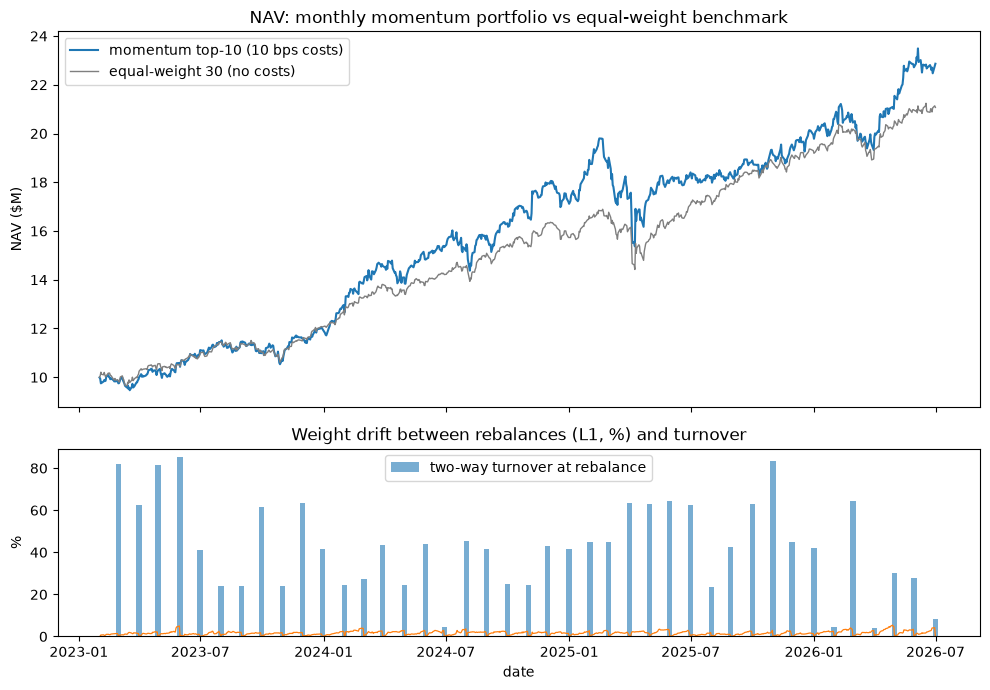

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(nav_s.index, nav_s / 1e6, label="momentum top-10 (10 bps costs)", color="tab:blue")
axes[0].plot(bench.index, bench / 1e6, label="equal-weight 30 (no costs)", color="tab:gray", lw=1)
axes[0].set_title("NAV: monthly momentum portfolio vs equal-weight benchmark")
axes[0].set_ylabel("NAV ($M)")
axes[0].legend()
axes[1].plot(drift_s.index, drift_s * 100, color="tab:orange", lw=0.9)
axes[1].bar(turn["date"], turn["turnover"] * 100, width=8, color="tab:blue", alpha=0.6,
            label="two-way turnover at rebalance")
axes[1].set_title("Weight drift between rebalances (L1, %) and turnover")
axes[1].set_ylabel("%")
axes[1].set_xlabel("date")
axes[1].legend()
fig.tight_layout()

## 5. "What was the book?" — three ways to reconstruct it

The audit story that versioning buys:

- **by data time** — `WHERE ts = ...` on the live table (the book struck
  at a given rebalance date),
- **by named snapshot** — `h5i('holdings', 'eoy-2025')`, pinned when the
  December 2025 rebalance was committed,
- **by commit time** — `read(as_of=...)` replays the table exactly as it
  existed when a given commit was the head. In this notebook all commits
  happened seconds apart, so `as_of` maps to run time rather than
  calendar time; in production, where each rebalance commits at its real
  EOD, `as_of="2025-12-31T23:00:00Z"` *is* the calendar question. Either
  way it is O(1) — no replay, no restore.

In [8]:
eoy = db.sql(
    """
    SELECT symbol, shares, weight FROM h5i('holdings', 'eoy-2025')
    WHERE ts = (SELECT max(ts) FROM h5i('holdings', 'eoy-2025'))
    ORDER BY weight DESC
    """
).to_pandas()
print("book at snapshot 'eoy-2025' (December 2025 rebalance):")
print(eoy.round(4).to_string(index=False))

v_dec = next(v["sequence"] for v in versions if v.get("note") == "rebalance 2025-12")
as_of_iso = pd.Timestamp(
    next(v for v in versions if v["sequence"] == v_dec)["committed_at_ns"], unit="ns", tz="UTC"
).isoformat()
by_version = db.read("holdings", version=v_dec)
by_time = db.read("holdings", as_of=as_of_iso)
assert by_version.equals(by_time)
print(f"\nread(version={v_dec}) == read(as_of='{as_of_iso}'): {by_version.num_rows} rows")

book at snapshot 'eoy-2025' (December 2025 rebalance):
symbol     shares  weight
  ABBV  8862.9568     0.1
    GS  2272.4677     0.1
   CAT  3474.4573     0.1
  CSCO 26056.9506     0.1
    GE  6439.8743     0.1
 GOOGL  6328.7478     0.1
   JNJ  9665.5130     0.1
   JPM  6226.8482     0.1
  NVDA 10620.5683     0.1
   IBM  6766.3007     0.1

read(version=36) == read(as_of='2026-07-23T03:09:50.879366055+00:00'): 360 rows


## Takeaways

- One rebalance = one commit with a note is the natural grain for a
  holdings table: `versions()` becomes the rebalance log, and no separate
  trades table is needed — trade lists and turnover fall out of
  `h5i('holdings', v)` FULL OUTER JOIN `h5i('holdings', v-1)`, and they
  reconciled exactly with the simulation's own ledger.
- Named snapshots (`'eoy-2025'`) give auditors a stable handle; version
  pins and `as_of` reads answer "what did the book look like" in O(1).
- The momentum-vs-benchmark result is period-dependent, as momentum
  always is (here it wins on return and loses on Sharpe) — the point is
  the machinery: costs, turnover (~40% two-way per month for a top-10
  momentum book) and drift are all measured from committed state, not
  recomputed hopefully.
- 12-1 momentum was two `lag()` windows in SQL; the only pandas is the
  simulation loop itself.

In [9]:
db.close()